In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../data/house_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [2]:
df.shape, df.isna().sum().sum()

((21613, 21), 0)

In [3]:
FEATURES = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors", "waterfront", "condition"]
df[FEATURES + ["price"]].describe().T

,count,mean,std,min,25%,50%,75%,max
bedrooms,21613.0,3.370842,0.930062,0.0,3.00,3.00,4.0,33.0
bathrooms,21613.0,2.114757,0.770163,0.0,1.75,2.25,2.5,8.0
sqft_living,21613.0,2079.899736,918.440897,290.0,1427.00,1910.00,2550.0,13540.0
sqft_lot,21613.0,15106.967566,41420.511515,520.0,5040.00,7618.00,10688.0,1651359.0
floors,21613.0,1.494309,0.539989,1.0,1.00,1.50,2.0,3.5
waterfront,21613.0,0.007542,0.086517,0.0,0.00,0.00,0.0,1.0
condition,21613.0,3.409430,0.650743,1.0,3.00,3.00,4.0,5.0
price,21613.0,540088.141767,367127.196483,75000.0,321950.00,450000.00,645000.0,7700000.0


In [4]:
df[FEATURES + ["price"]].corr()["price"].sort_values(ascending=False)

price          1.000000
sqft_living    0.702035
bathrooms      0.525138
bedrooms       0.308350
waterfront     0.266369
floors         0.256794
sqft_lot       0.089661
condition      0.036362
Name: price, dtype: float64

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), FEATURES + ["price"]):
    ax.hist(df[col], bins=40, color="tab:blue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

<Figure size 1600x700 with 8 Axes>

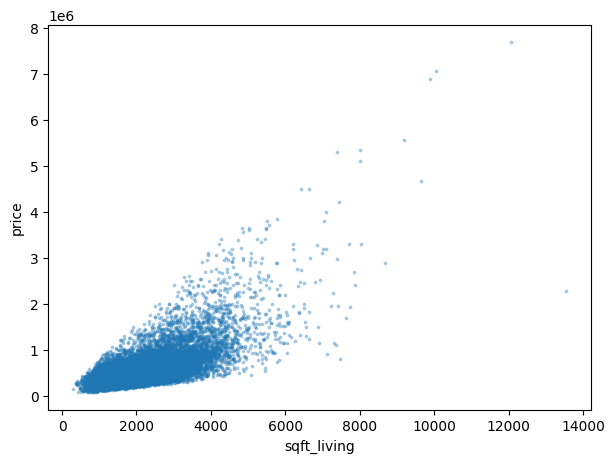

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(df.sqft_living, df.price, s=3, alpha=0.3)
plt.xlabel("sqft_living")
plt.ylabel("price")
plt.show()

In [7]:
df.groupby("condition")["price"].agg(["count", "mean", "median"])

,count,mean,median
condition,,,
1,30,334431.666667,262500.0
2,172,327287.145349,279000.0
3,14031,542012.578148,450000.0
4,5679,521200.390033,440000.0
5,1701,612418.089359,526000.0
